In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [4]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

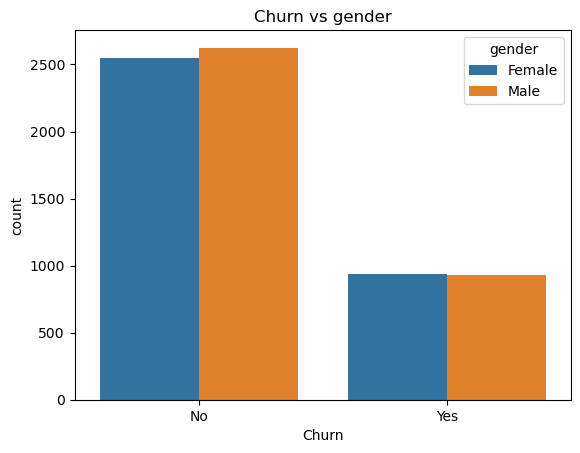

In [57]:
sns.countplot(x="Churn",hue="gender",data=df)
plt.title("Churn vs gender")
plt.savefig("Churn vs gender")
#Churn does not depend on gender and most people do not churn

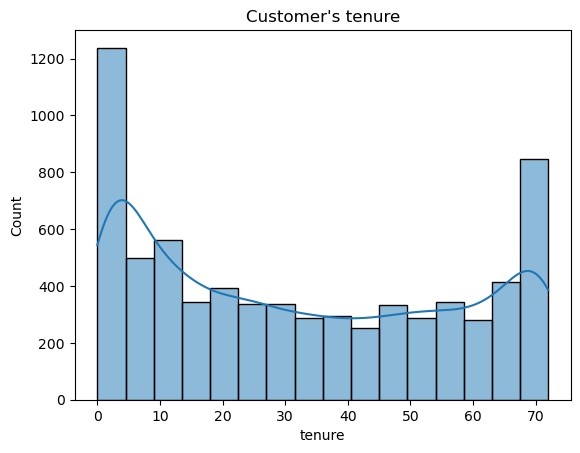

In [59]:
sns.histplot(x="tenure",data=df,kde=True)
plt.title("Customer's tenure")
plt.savefig("Customer's tenure")
#it shows customers either do leave early or stay more

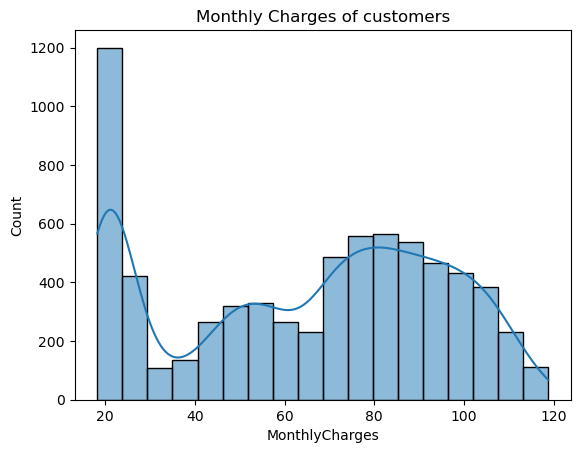

In [60]:
sns.histplot(x="MonthlyCharges",data=df,kde=True)
plt.title("Monthly Charges of customers")
plt.savefig("Monthly Charges of customers")
#customers have different plans so different peaks

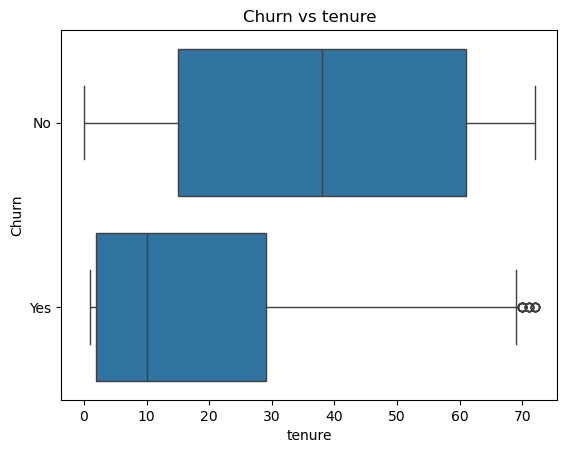

In [61]:
sns.boxplot(x="tenure",y="Churn",data=df)
plt.title("Churn vs tenure")
plt.savefig("Churn vs tenure")
#customers who churn have less tenure and who dont churn have more tenure

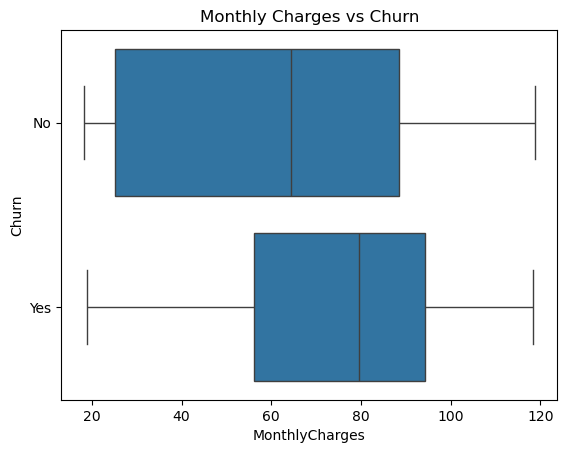

In [62]:
sns.boxplot(x="MonthlyCharges",y="Churn",data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig("Monthly Charges vs Churn")
#customers who churn have more likely high monthly charges

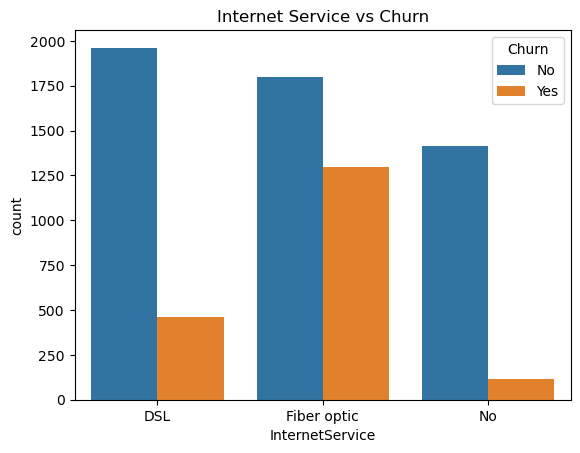

In [63]:
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.title("Internet Service vs Churn")
plt.savefig("Internet Service vs Churn")
#most people who churn used fibre optics before

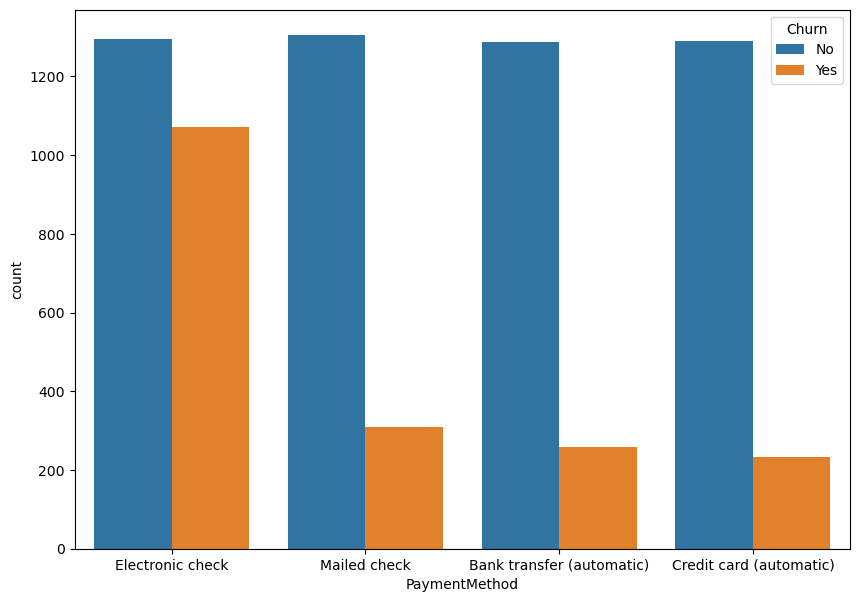

In [76]:
#customers who pay online are more likely to churn
plt.figure(figsize=(10,7))
sns.countplot(x="PaymentMethod",hue="Churn",data=df)
plt.savefig("Payment Method vs Churn")

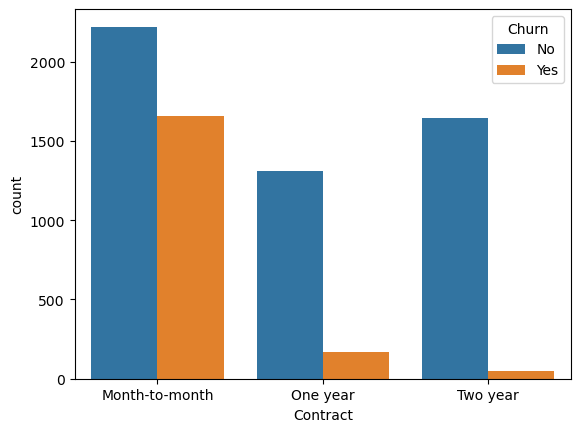

In [78]:
#Customers who use month to month recharges are more likely to churn
sns.countplot(x="Contract",hue="Churn",data=df)
plt.savefig("Contract vs Churn")

In [79]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
#converting categorical data into numerical data

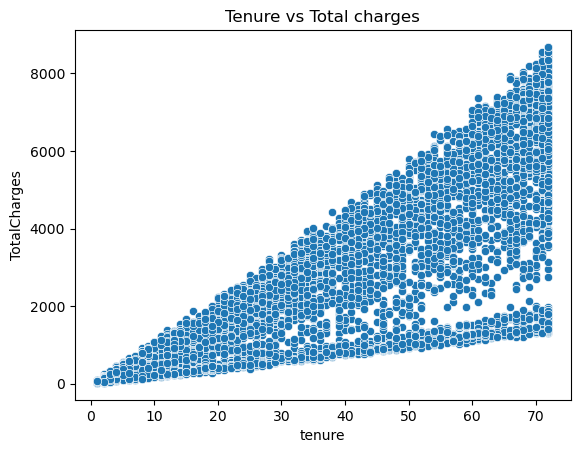

In [64]:
sns.scatterplot(x="tenure",y="TotalCharges",data=df)
plt.title("Tenure vs Total charges")
plt.savefig("Tenure vs Total charges")
#as people's totalcharges increases, tenure also increases as they add up

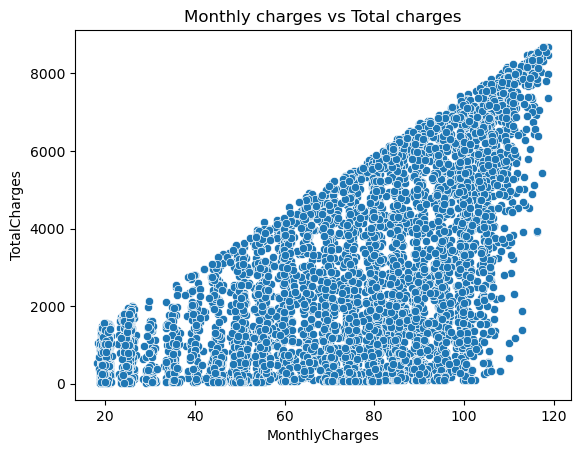

In [65]:
sns.scatterplot(x="MonthlyCharges",y="TotalCharges",data=df)
plt.title("Monthly charges vs Total charges")
plt.savefig("Monthly charges vs Total charges")
#as monthly charges increases total bill also increases

<Axes: title={'center': 'Heatmap'}>

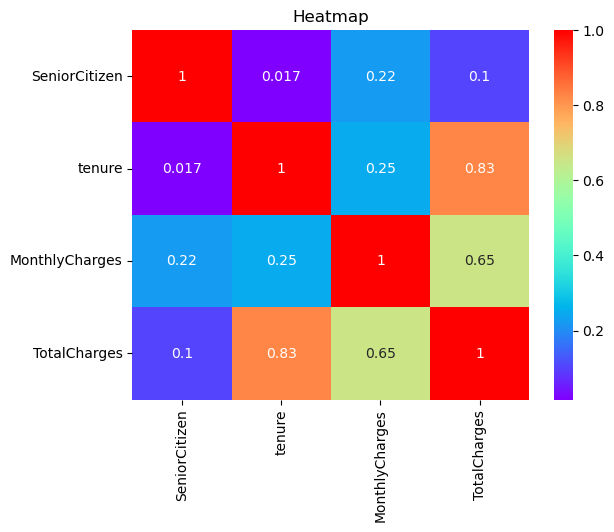

In [66]:
corr=df.corr(numeric_only=True)
plt.title("Heatmap")
plt.savefig("Heatmap")
sns.heatmap(corr,annot=True,cmap="rainbow")
#Tenure and TotalCharges are (0.83) means people who stay longer have high total charges also
#MonthlyCharges and TotalCharges are (0.65) means if monthly charges rises the total will go up automatically. 
#SeniorCitizen has very weak correlations with the others.

In [21]:
x=df.drop("Churn",axis=1)
y=df["Churn"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [55]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 20)
(1409, 20)
(5634,)
(1409,)


In [56]:
print(x_train)
print(x_test)
print(y_train)
print(y_test)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
2142  4223-BKEOR  Female              0      No        Yes      21   
1623  6035-RIIOM  Female              0      No         No      54   
6074  3797-VTIDR    Male              0     Yes         No       1   
1362  2568-BRGYX    Male              0      No         No       4   
6754  2775-SEFEE    Male              0      No        Yes       0   
...          ...     ...            ...     ...        ...     ...   
3772  0684-AOSIH    Male              0     Yes         No       1   
5191  5982-PSMKW  Female              0     Yes        Yes      23   
5226  8044-BGWPI    Male              0     Yes        Yes      12   
5390  7450-NWRTR    Male              1      No         No      12   
860   4795-UXVCJ    Male              0      No         No      26   

     PhoneService     MultipleLines InternetService       OnlineSecurity  \
2142          Yes                No             DSL                  Yes   
1623   

In [80]:
x_train.to_csv("X_train_result",index=False)
y_train.to_csv("Y_train_result",index=False)
x_test.to_csv("X_test_result",index=False)
y_test.to_csv("Y_test_result",index=False)